In [2]:
# Quantum correction calculations to the linear E and in B magnetoconductivity. Positional shift formalism.
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Field_Induced_Hall_Effect
using Brillouin
using Bravais
using CairoMakie, BZpaths

In [3]:
pathof(Optics_in_the_length_gauge)

"/Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/95v8z/src/Optics_in_the_length_gauge.jl"

In [26]:
function rotate_z(θ, v)
    # θ = π / 3  # 60 degrees
    R = [
        cos(θ)  -sin(θ)  0;
        sin(θ)   cos(θ)  0;
        0        0       1
    ]
    return R * v
end

# KPATH
Γ = [0,0,0]
A = [0,0, π]
M =  2π/3 *  [1, 0, 0]
K1 = 2π/3 * [1, -1/sqrt(3), 0];
K2 = 2π/3 * [1, 1/sqrt(3), 0];

M = rotate_z(π/3, M)
K1 = rotate_z(2pi/3, K1)
K2 = rotate_z(pi/3, K2)


3-element Vector{Float64}:
 4.760838790634402e-17
 2.4183991523122903
 0.0

In [31]:



function bands(q, p, i)
    mat = threeband_ferroaxial_ham3d(q,p.μ,p.Δ,p.t,p.tp, p.tpz, p.tc, p.U, p.t_ca, p.t_cb)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial(p; a = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    # Rs = (a .* [3/2, √3/2, 0], a .* [-3/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
    sgnum = 143                           # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tp) eV")
    for i in 1:3
        dispersion(q) = bands(q, p, i)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end



function bands_ferroaxial_Gamma_M_K(p; a = 1)
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
                 # point group (144 = p3_1)
    N = 200    #kpoints

    mysimpath = [Γ, M, K1, Γ .+ 1e-4, A .+ 1e-3, K2]
    ks = interpolate(mysimpath, N)
    ticks_vals = [bands(kpoint, p, 1) for kpoint in mysimpath]
    xvals = 1:length(ks)
    
    yvals_1 = real.([bands(k, p, 1) for k in ks])
    
    yvals_2 = real.([bands(k, p, 2) for k in ks])
    yvals_3 = real.([bands(k, p, 3) for k in ks])

    

    position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "μ = $(p.μ), Δ = $(p.Δ), t_perp = $(p.tpz), t = $(p.t), t2 = $(p.tc), t3 = $(p.tp), t_ca = $(p.t_ca), t_cb = $(p.t_cb), U = $(p.U)",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :black)
    lines!(ax, xvals, yvals_2, color = :black)
    lines!(ax, xvals, yvals_3, color = :black)
    # ylims!(ax, -10,9)
    # ax.yticks = (-10:9, string.(-10:9))
    xvals, fig
end


bands_ferroaxial_Gamma_M_K (generic function with 1 method)

[1, 33, 51, 88, 136, 51]


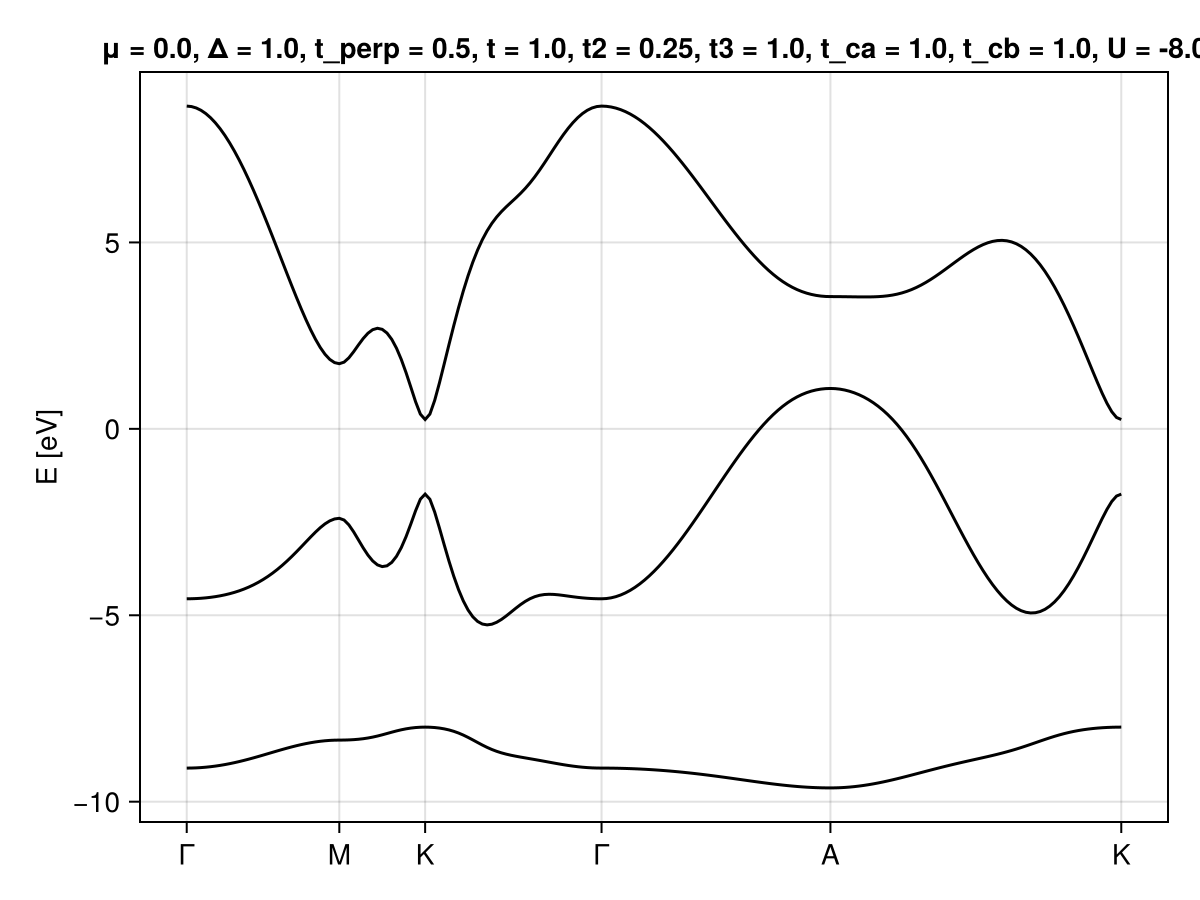

In [38]:
vals, fig = bands_ferroaxial_Gamma_M_K(modelpresets_3bandFA(; μ =0, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25, U = -8, t_ca = 1, t_cb = 1));
fig

## Fij Line

In [ ]:

using PhysicalConstants
using PhysicalConstants.CODATA2018
using Unitful
using SparseArrays
using StaticArrays
using Parameters
ħ = PhysicalConstants.CODATA2018.ħ
e = PhysicalConstants.CODATA2018.e



Fij_Gamma_M_K(p, comp_pres, dirF1, dirF2, band; a = 1) = Oij_Gamma_M_K(Optics_in_the_length_gauge.F,p,  comp_pres, dirF1, dirF2, band, a = a )
function Oij_Gamma_M_K(func, p, comp_pres, dirF1, dirF2, band; a = 1)
    N = 400    #kpoints
    mysimpath = [Γ, M .+ 1e-3 , K1 .+ 1e-3, Γ .+ 1e-3, A .+ 1e-3 , K2]
    Fab(comp_pres, q, band) = func(comp_pres, q, dirF1, dirF2)[band]
    ks = interpolate(mysimpath, N)
    ticks_vals = [Fab(comp_pres, kpoint, 1 ) for kpoint in mysimpath]
    units = 1#(e/ħ |> u"T^-1*Å^-2").val # Fab is computed in Å^3 so the result is Å/T
    xvals = 1:length(ks)
    yvals_1 = [Fab(comp_pres, q, 1 ) for q in ks]./units
    yvals_2 = [Fab(comp_pres, q, 2) for q in ks]./units
    
    # position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    position =  [1, 66, 103, 178, 275, 398]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K1", "Γ", "A", "K2"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "F$(dirF1)$(dirF2) [Å^3]",  title = "Δ = $(p.Δ) eV, t_perp = $(p.tpz) eV, t = $(p.t) eV, t2 = $(p.tc), t3 = $(p.tp) eV, QM on = $(comp_pres.QM_switch)",  xticks=xticks)
    lines!(ax, xvals, yvals_1, color = :red, label = "Lower band")
    scatter!(ax, xvals, yvals_1, color = :red)#, label = "Lower band")
    lines!(ax, xvals, yvals_2, color = :black, label = "Uper band")
    
    xlims!(ax, 1, N)
    if maximum(abs.(yvals_1))< 1e-6
        ylims!(ax, -1e-7,1e-7)
    end
    # ylims!(ax, -0.025,0.025)
    ax.yticks = (-0.15:0.05:0.4)#, string.(-10:9))
    axislegend(ax, position = :lt)
    return yvals_1, yvals_2, fig
end






In [ ]:
band = 1
a = 1.0
R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(a)
Rs = [R1,R2,R3]

p = modelpresets_3bandFA(; μ =1.75, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25)
kws = (fermi_surface = false, QM_switch = true)
comp_pres = sigma_abc_ferroaxial_wrapper_3d_3bands(p; kws...);


In [ ]:

dir1 = :x
dir2 = :z
# Method reusing the OMM
yvals0_1, yvals0_2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1)
fig
